# 🧠 Notebook 2: Baseline CNN-Transformer untuk Lokalisasi PVC/VT
## Perbandingan 3 Varian Transformer: Transformer Encoder, PatchTST, Hierarchical Transformer

**Pipeline:**
```
DATA DWT → SPLIT 80/20 → K-Fold 5 (pada 80% DWT)
  → CNN Feature Extractor (ekstraksi fitur)
  → 3 Transformer (lokalisasi): Encoder / PatchTST / Hierarchical
  → Final Training (semua 3 model, 100% data train)
  → Final Testing (20% data DWT) → SHAP
```

**Klasifikasi 3 Kelas Utama:** RVOT, LVOT, Non-OT
**Supplementary:** 5 pasien LV Non-OT (Summit) diprediksi secara terpisah (eksploratif).

**Metrik Evaluasi (sesuai Proposal TA):**
Accuracy, Sensitivity, Specificity, F1-Score, AUC-ROC, Confusion Matrix

---

## 1. Import Library & Konfigurasi

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, time, json, math, copy, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

print(f"✅ PyTorch {torch.__version__} | Device: {DEVICE}")

plt.rcParams.update({
    'figure.figsize': (16, 8), 'figure.dpi': 100, 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'axes.grid': True, 'grid.alpha': 0.3,
})

BASE_DIR = Path('.')
PREPROCESSED_DIR = BASE_DIR / 'preprocessed_data'
DWT_DIR = PREPROCESSED_DIR / 'dwt_denoised'
OUTPUT_DIR = BASE_DIR / 'baseline_results'
OUTPUT_DIR.mkdir(exist_ok=True)

# Kelas target utama: 3 kelas
CLASS_NAMES = ['LVOT', 'Non-OT', 'RVOT']
N_CLASSES = len(CLASS_NAMES)

CONFIG = {
    'segment_length': 5000, 'sampling_rate': 1000, 'n_leads': 12,
    'n_classes': N_CLASSES,
    'n_folds': 5, 'batch_size': 32, 'epochs': 50,
    'learning_rate': 1e-3, 'weight_decay': 1e-4, 'patience': 10,
    'cnn_channels': [32, 64, 128, 256], 'cnn_kernels': [7, 5, 3, 3],
    'transformer_heads': 4, 'transformer_layers': 2,
    'transformer_dropout': 0.2, 'fc_dropout': 0.3,
    'patch_size': 16,  # untuk PatchTST
}

LEADS = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
MODEL_NAMES = ['Transformer Encoder', 'PatchTST', 'Hierarchical Transformer']
MODEL_COLORS = ['#2563EB', '#DC2626', '#059669']

# Mapping Sublocation
RVOT_SUBS = ['PosteriorSeptal', 'AnteriorSeptal', 'FreeWall', 'RVOTOther']
LVOT_SUBS = ['LCC', 'RCC', 'AMC', 'LCC-RCC Ommisure']
NONOT_SUBS = ['LC', 'AC', 'RC']
LV_NONOT_SUBS = ['Summit']

print(f"\n📋 Konfigurasi:")
for k, v in CONFIG.items():
    print(f"   {k}: {v}")
print(f"\n🏷️ Kelas Target ({N_CLASSES}): {CLASS_NAMES}")

✅ PyTorch 2.2.2 | Device: mps

📋 Konfigurasi:
   segment_length: 5000
   sampling_rate: 1000
   n_leads: 12
   n_classes: 3
   n_folds: 5
   batch_size: 32
   epochs: 50
   learning_rate: 0.001
   weight_decay: 0.0001
   patience: 10
   cnn_channels: [32, 64, 128, 256]
   cnn_kernels: [7, 5, 3, 3]
   transformer_heads: 4
   transformer_layers: 2
   transformer_dropout: 0.2
   fc_dropout: 0.3
   patch_size: 16

🏷️ Kelas Target (3): ['LVOT', 'Non-OT', 'RVOT']


---
## 2. Load Data (Mapping 3 Kelas + Supplementary)

In [2]:
split_meta = pd.read_csv(PREPROCESSED_DIR / 'split_metadata.csv')
train_ids = np.load(PREPROCESSED_DIR / 'train_ids.npy', allow_pickle=True)
test_ids = np.load(PREPROCESSED_DIR / 'test_ids.npy', allow_pickle=True)
df_diag = pd.read_excel(BASE_DIR / 'Diagnosis.xlsx')

def map_classes(row):
    sub = row['Sublocation']
    if pd.isna(sub): return None
    if sub in RVOT_SUBS: return 'RVOT'
    if sub in LVOT_SUBS: return 'LVOT'
    if sub in NONOT_SUBS: return 'Non-OT'
    if sub in LV_NONOT_SUBS: return 'LV Non-OT'
    return None

df_diag['Class'] = df_diag.apply(map_classes, axis=1)

# Pisahkan data utama (3 kelas) dan supplementary (LV Non-OT)
df_main = df_diag[df_diag['Class'].isin(CLASS_NAMES)].reset_index(drop=True)
df_suppl = df_diag[df_diag['Class'] == 'LV Non-OT'].reset_index(drop=True)
n_dropped = df_diag['Class'].isna().sum()

# LabelEncoder untuk 3 kelas
le = LabelEncoder()
le.fit(CLASS_NAMES)

# Filter train/test IDs untuk eksperimen utama
main_ids_str = set(df_main['HospitalID'].astype(str).values)
train_ids_main = np.array([x for x in train_ids if str(x) in main_ids_str])
test_ids_main = np.array([x for x in test_ids if str(x) in main_ids_str])

# ID untuk supplementary
suppl_ids = df_suppl['HospitalID'].values

print("=" * 70)
print("📂 DATA LOADED — 3 KELAS LOKALISASI PVC")
print("=" * 70)
print(f"   Total pasien awal       : {len(df_diag)}")
print(f"   Dropped (no sublocation): {n_dropped}")
print(f"   Eksperimen Utama (3 cls): {len(df_main)} pasien")
print(f"   Supplementary (LV Non-OT): {len(df_suppl)} pasien")
print(f"   Training (80%)          : {len(train_ids_main)} pasien")
print(f"   Testing  (20%)          : {len(test_ids_main)} pasien")
print(f"\n🏷️ Distribusi 3 Kelas Utama:")
for cls in CLASS_NAMES:
    n = (df_main['Class'] == cls).sum()
    print(f"   {cls:<10}: {n:>4} ({n/len(df_main)*100:.1f}%)")
print(f"\n   Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

📂 DATA LOADED — 3 KELAS LOKALISASI PVC
   Total pasien awal       : 334
   Dropped (no sublocation): 40
   Eksperimen Utama (3 cls): 289 pasien
   Supplementary (LV Non-OT): 5 pasien
   Training (80%)          : 230 pasien
   Testing  (20%)          : 59 pasien

🏷️ Distribusi 3 Kelas Utama:
   LVOT      :   71 (24.6%)
   Non-OT    :  124 (42.9%)
   RVOT      :   94 (32.5%)

   Label encoding: {'LVOT': 0, 'Non-OT': 1, 'RVOT': 2}


---
## 3. Preprocessing — Segmentation & Normalisasi

In [3]:
def load_ecg_signals(hospital_ids, ecg_dir, source_name=""):
    signals, errors = {}, []
    for hid in hospital_ids:
        try:
            df = pd.read_csv(ecg_dir / f"{hid}.csv")
            signals[hid] = df[LEADS].values
        except Exception as e:
            errors.append((hid, str(e)))
    if errors:
        print(f"   ⚠️ {len(errors)} errors loading {source_name}")
    print(f"   ✅ Loaded {len(signals)} signals from {source_name}")
    return signals

def segment_signals(signals, labels_dict, segment_length=5000, overlap=0.5):
    X_list, y_list, group_list = [], [], []
    step = int(segment_length * (1 - overlap))
    for hid, signal in signals.items():
        if hid not in labels_dict:
            continue
        n_samples = len(signal)
        label = labels_dict[hid]
        if n_samples < segment_length:
            padded = np.zeros((segment_length, signal.shape[1]))
            padded[:n_samples] = signal
            X_list.append(padded.T)
            y_list.append(label)
            group_list.append(hid)
        else:
            start = 0
            while start + segment_length <= n_samples:
                segment = signal[start:start + segment_length]
                X_list.append(segment.T)
                y_list.append(label)
                group_list.append(hid)
                start += step
    return np.array(X_list, dtype=np.float32), np.array(y_list), np.array(group_list)

In [4]:
print("⏳ Loading DWT denoised signals (training)...")
train_signals = load_ecg_signals(train_ids_main, DWT_DIR, "Train 80% (DWT)")

print("⏳ Loading DWT denoised signals (testing)...")
test_signals = load_ecg_signals(test_ids_main, DWT_DIR, "Test 20% (DWT)")

print("⏳ Loading DWT denoised signals (supplementary)...")
suppl_signals = load_ecg_signals(suppl_ids, DWT_DIR, "Supplementary (DWT)")

# Label dicts
label_dict_main = {}
for _, row in df_main.iterrows():
    hid = row['HospitalID']
    label_dict_main[hid] = le.transform([row['Class']])[0]

⏳ Loading DWT denoised signals (training)...
   ✅ Loaded 230 signals from Train 80% (DWT)
⏳ Loading DWT denoised signals (testing)...
   ✅ Loaded 59 signals from Test 20% (DWT)
⏳ Loading DWT denoised signals (supplementary)...
   ✅ Loaded 5 signals from Supplementary (DWT)


In [5]:
print("\n⏳ Segmentasi sinyal (Overlap 50%)...")
X_train_all, y_train_all, groups_train = segment_signals(
    train_signals, label_dict_main, CONFIG['segment_length'])
X_test_all, y_test_all, groups_test = segment_signals(
    test_signals, label_dict_main, CONFIG['segment_length'])

# Dummy label (-1) for supplementary during segmentation
suppl_label_dict = {hid: -1 for hid in suppl_ids}
X_suppl_all, _, groups_suppl = segment_signals(
    suppl_signals, suppl_label_dict, CONFIG['segment_length'])

print(f"\n📊 Hasil Segmentasi:")
print(f"   Training : {X_train_all.shape}  labels={dict(zip(*np.unique(y_train_all, return_counts=True)))}")
print(f"   Testing  : {X_test_all.shape}  labels={dict(zip(*np.unique(y_test_all, return_counts=True)))}")
print(f"   Suppl    : {X_suppl_all.shape}")


⏳ Segmentasi sinyal (Overlap 50%)...

📊 Hasil Segmentasi:
   Training : (2274, 12, 5000)  labels={0: 440, 1: 985, 2: 849}
   Testing  : (533, 12, 5000)  labels={0: 120, 1: 213, 2: 200}
   Suppl    : (40, 12, 5000)


In [6]:
print("\n⏳ Normalisasi (StandardScaler fit on training)...")
n_seg, n_leads, seg_len = X_train_all.shape
X_flat = X_train_all.transpose(0, 2, 1).reshape(-1, n_leads)
scaler = StandardScaler()
scaler.fit(X_flat)

X_train_scaled = scaler.transform(X_flat).reshape(n_seg, seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)

X_test_flat = X_test_all.transpose(0, 2, 1).reshape(-1, n_leads)
X_test_scaled = scaler.transform(X_test_flat).reshape(X_test_all.shape[0], seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)

X_suppl_flat = X_suppl_all.transpose(0, 2, 1).reshape(-1, n_leads)
X_suppl_scaled = scaler.transform(X_suppl_flat).reshape(X_suppl_all.shape[0], seg_len, n_leads).transpose(0, 2, 1).astype(np.float32)

print(f"   Train scaled: {X_train_scaled.shape}, mean={X_train_scaled.mean():.4f}, std={X_train_scaled.std():.4f}")
print(f"   Test  scaled: {X_test_scaled.shape}")
print(f"   Suppl scaled: {X_suppl_scaled.shape}")


⏳ Normalisasi (StandardScaler fit on training)...
   Train scaled: (2274, 12, 5000), mean=0.0000, std=1.0000
   Test  scaled: (533, 12, 5000)
   Suppl scaled: (40, 12, 5000)


---
## 4. K-Fold Cross-Validation Setup

In [7]:
class ECGDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y) if y is not None else None
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        if self.y is not None:
            return self.X[idx], self.y[idx]
        return self.X[idx]

skgf = StratifiedGroupKFold(n_splits=CONFIG['n_folds'], shuffle=True, random_state=SEED)

print("=" * 70)
print(f"📊 {CONFIG['n_folds']}-FOLD STRATIFIED GROUP K-FOLD (3 KELAS)")
print("=" * 70)

for fold, (train_idx, val_idx) in enumerate(skgf.split(X_train_scaled, y_train_all, groups_train)):
    tp = np.unique(groups_train[train_idx])
    vp = np.unique(groups_train[val_idx])
    assert len(set(tp) & set(vp)) == 0, "DATA LEAKAGE!"
    print(f"   Fold {fold+1}: Train {len(train_idx)} seg ({len(tp)} pat) | Val {len(val_idx)} seg ({len(vp)} pat) | ✅ No leakage")

📊 5-FOLD STRATIFIED GROUP K-FOLD (3 KELAS)
   Fold 1: Train 1808 seg (184 pat) | Val 466 seg (46 pat) | ✅ No leakage
   Fold 2: Train 1804 seg (184 pat) | Val 470 seg (46 pat) | ✅ No leakage
   Fold 3: Train 1817 seg (184 pat) | Val 457 seg (46 pat) | ✅ No leakage
   Fold 4: Train 1839 seg (184 pat) | Val 435 seg (46 pat) | ✅ No leakage
   Fold 5: Train 1828 seg (184 pat) | Val 446 seg (46 pat) | ✅ No leakage


---
## 5. Model Architectures (Output 3 Kelas)

In [8]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=12, channels=[32, 64, 128, 256], kernels=[7, 5, 3, 3]):
        super().__init__()
        layers = []
        prev_ch = in_channels
        for ch, k in zip(channels, kernels):
            layers.extend([
                nn.Conv1d(prev_ch, ch, kernel_size=k, padding=k // 2),
                nn.BatchNorm1d(ch),
                nn.ReLU(inplace=True),
                nn.MaxPool1d(kernel_size=2, stride=2),
            ])
            prev_ch = ch
        self.features = nn.Sequential(*layers)
        self.out_channels = channels[-1]

    def forward(self, x):
        return self.features(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1), :])

class CNNTransformerEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])
        self.pos_enc = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config['transformer_layers'])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, config['n_classes']))

    def forward(self, x):
        features = self.cnn(x)
        features = features.permute(0, 2, 1)
        features = self.pos_enc(features)
        features = self.transformer(features)
        pooled = features.mean(dim=1)
        return self.classifier(pooled)

class CNNPatchTST(nn.Module):
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.patch_size = config['patch_size']
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])
        self.patch_proj = nn.Linear(self.patch_size * d_model, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=config['transformer_layers'])
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, config['n_classes']))

    def forward(self, x):
        features = self.cnn(x)
        features = features.permute(0, 2, 1)
        B, S, D = features.shape
        n_patches = S // self.patch_size
        features = features[:, :n_patches * self.patch_size, :]
        patches = features.reshape(B, n_patches, self.patch_size * D)
        patches = self.patch_proj(patches)
        patches = self.pos_enc(patches)
        patches = self.transformer(patches)
        pooled = patches.mean(dim=1)
        return self.classifier(pooled)

class CNNHierarchicalTransformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        d_model = config['cnn_channels'][-1]
        self.cnn = CNNFeatureExtractor(config['n_leads'], config['cnn_channels'], config['cnn_kernels'])
        self.pos_enc_1 = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        enc_layer_1 = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer_level1 = nn.TransformerEncoder(enc_layer_1, num_layers=1)
        self.downsample = nn.Sequential(
            nn.Conv1d(d_model, d_model, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm1d(d_model),
            nn.ReLU(inplace=True))
        self.pos_enc_2 = PositionalEncoding(d_model, dropout=config['transformer_dropout'])
        enc_layer_2 = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=config['transformer_heads'],
            dim_feedforward=d_model * 4, dropout=config['transformer_dropout'], batch_first=True)
        self.transformer_level2 = nn.TransformerEncoder(enc_layer_2, num_layers=1)
        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, d_model // 2), nn.ReLU(inplace=True),
            nn.Dropout(config['fc_dropout']),
            nn.Linear(d_model // 2, config['n_classes']))

    def forward(self, x):
        features = self.cnn(x)
        seq = features.permute(0, 2, 1)
        seq = self.pos_enc_1(seq)
        local_out = self.transformer_level1(seq)
        ds = local_out.permute(0, 2, 1)
        ds = self.downsample(ds)
        ds = ds.permute(0, 2, 1)
        ds = self.pos_enc_2(ds)
        global_out = self.transformer_level2(ds)
        pooled = global_out.mean(dim=1)
        return self.classifier(pooled)

print("\n✅ Semua model terverifikasi! Output: 3 kelas")


✅ Semua model terverifikasi! Output: 3 kelas


---
## 6. Training Functions

In [9]:
def compute_metrics(y_true, y_pred, y_prob, n_classes=3):
    acc = accuracy_score(y_true, y_pred)
    sensitivity = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n_classes)))
    specificities = []
    for i in range(n_classes):
        tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + cm[i, i]
        fp = cm[:, i].sum() - cm[i, i]
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificities.append(spec)
    specificity = np.mean(specificities)
    
    try:
        if y_prob.ndim == 2 and y_prob.shape[1] == n_classes:
            auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
        else:
            auc = 0.0
    except Exception:
        auc = 0.0
    
    return {'accuracy': acc, 'sensitivity': sensitivity, 'specificity': specificity,
            'f1': f1, 'auc': auc}

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        out = model(X_b)
        loss = criterion(out, y_b)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y_b)
        correct += out.argmax(1).eq(y_b).sum().item()
        total += len(y_b)
    return total_loss / total, correct / total

def evaluate(model, loader, criterion, device, n_classes=3):
    model.eval()
    total_loss, all_preds, all_probs, all_labels = 0, [], [], []
    total = 0
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, (tuple, list)) and len(batch) == 2:
                X_b, y_b = batch
                X_b, y_b = X_b.to(device), y_b.to(device)
            else:
                X_b = batch.to(device) if not isinstance(batch, (tuple, list)) else batch[0].to(device)
                y_b = None
                
            # Support evaluating without labels (for supplementary analysis)
            out = model(X_b)
            if y_b is not None and criterion is not None and y_b[0] != -1:
                loss = criterion(out, y_b)
                total_loss += loss.item() * len(y_b)
                total += len(y_b)
                all_labels.extend(y_b.cpu().numpy())
            probs = torch.softmax(out, dim=1)
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    preds = np.array(all_preds)
    probs = np.array(all_probs)
    
    if len(all_labels) > 0:
        labels = np.array(all_labels)
        metrics = compute_metrics(labels, preds, probs, n_classes)
        metrics['loss'] = total_loss / total
        return metrics, preds, probs, labels
    else:
        return None, preds, probs, None

In [10]:
# Class weights untuk imbalance (3 kelas)
class_counts = np.bincount(y_train_all, minlength=N_CLASSES)
class_weights = 1.0 / (class_counts + 1e-8)
class_weights = class_weights / class_weights.sum() * N_CLASSES
class_weights = torch.FloatTensor(class_weights)
print(f"📊 Class weights (3 kelas):")
for i, cls in enumerate(le.classes_):
    print(f"   {cls:<12}: count={class_counts[i]:>4}, weight={class_weights[i]:.3f}")

📊 Class weights (3 kelas):
   LVOT        : count= 440, weight=1.527
   Non-OT      : count= 985, weight=0.682
   RVOT        : count= 849, weight=0.791


---
## 7. K-Fold Training — 3 Model Transformer

In [11]:
print("=" * 70)
print(f"🚀 TRAINING {CONFIG['n_folds']}-FOLD CV × 3 MODEL TRANSFORMER (3 KELAS)")
print("=" * 70)

all_results = {}
all_histories = {}
all_best_models = {}

model_classes = [CNNTransformerEncoder, CNNPatchTST, CNNHierarchicalTransformer]

for model_idx, (model_name, ModelClass) in enumerate(zip(MODEL_NAMES, model_classes)):
    print(f"\n{'═'*70}")
    print(f"🧠 MODEL {model_idx+1}/3: {model_name}")
    print(f"{'═'*70}")

    fold_results = []
    fold_histories = []
    fold_best_models = []

    for fold, (train_idx, val_idx) in enumerate(skgf.split(X_train_scaled, y_train_all, groups_train)):
        print(f"\n   ── Fold {fold+1}/{CONFIG['n_folds']} ──")
        X_ft, y_ft = X_train_scaled[train_idx], y_train_all[train_idx]
        X_fv, y_fv = X_train_scaled[val_idx], y_train_all[val_idx]

        train_loader = DataLoader(ECGDataset(X_ft, y_ft), batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)
        val_loader = DataLoader(ECGDataset(X_fv, y_fv), batch_size=CONFIG['batch_size'], shuffle=False)

        model = ModelClass(CONFIG).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
        optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'])

        best_f1, patience_cnt, best_state, best_ep = 0, 0, None, 0
        history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'val_auc': []}

        for epoch in range(CONFIG['epochs']):
            t0 = time.time()
            tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
            val_m, _, _, _ = evaluate(model, val_loader, criterion, DEVICE, N_CLASSES)
            scheduler.step()

            history['train_loss'].append(tr_loss)
            history['train_acc'].append(tr_acc)
            history['val_loss'].append(val_m['loss'])
            history['val_acc'].append(val_m['accuracy'])
            history['val_f1'].append(val_m['f1'])
            history['val_auc'].append(val_m['auc'])

            if (epoch + 1) % 10 == 0 or epoch == 0:
                print(f"      Ep {epoch+1:3d} | TrLoss {tr_loss:.4f} TrAcc {tr_acc:.3f} | "
                      f"ValAcc {val_m['accuracy']:.3f} | ValF1 {val_m['f1']:.3f} | "
                      f"ValAUC {val_m['auc']:.3f} | {time.time()-t0:.1f}s")

            if val_m['f1'] > best_f1:
                best_f1 = val_m['f1']
                patience_cnt = 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
                best_ep = epoch + 1
            else:
                patience_cnt += 1
                if patience_cnt >= CONFIG['patience']:
                    print(f"      ⏹️ Early stop ep {epoch+1} (best: {best_ep})")
                    break

        model.load_state_dict(best_state)
        model.to(DEVICE)
        final_m, _, _, _ = evaluate(model, val_loader, criterion, DEVICE, N_CLASSES)
        final_m['fold'] = fold + 1
        final_m['best_epoch'] = best_ep
        fold_results.append(final_m)
        fold_histories.append(history)
        fold_best_models.append(best_state)

        print(f"      ✅ Best ep {best_ep}: Acc={final_m['accuracy']:.3f} Sens={final_m['sensitivity']:.3f} "
              f"Spec={final_m['specificity']:.3f} F1={final_m['f1']:.3f} AUC={final_m['auc']:.3f}")

    all_results[model_name] = fold_results
    all_histories[model_name] = fold_histories
    all_best_models[model_name] = fold_best_models

🚀 TRAINING 5-FOLD CV × 3 MODEL TRANSFORMER (3 KELAS)

══════════════════════════════════════════════════════════════════════
🧠 MODEL 1/3: Transformer Encoder
══════════════════════════════════════════════════════════════════════

   ── Fold 1/5 ──
      Ep   1 | TrLoss 0.9908 TrAcc 0.438 | ValAcc 0.414 | ValF1 0.357 | ValAUC 0.735 | 15.8s
      Ep  10 | TrLoss 0.8407 TrAcc 0.506 | ValAcc 0.530 | ValF1 0.464 | ValAUC 0.724 | 17.8s
      ⏹️ Early stop ep 13 (best: 3)
      ✅ Best ep 3: Acc=0.575 Sens=0.605 Spec=0.774 F1=0.587 AUC=0.755

   ── Fold 2/5 ──
      Ep   1 | TrLoss 0.9538 TrAcc 0.467 | ValAcc 0.436 | ValF1 0.333 | ValAUC 0.684 | 22.9s
      Ep  10 | TrLoss 0.8269 TrAcc 0.554 | ValAcc 0.534 | ValF1 0.441 | ValAUC 0.698 | 22.0s
      ⏹️ Early stop ep 13 (best: 3)
      ✅ Best ep 3: Acc=0.591 Sens=0.608 Spec=0.732 F1=0.519 AUC=0.720

   ── Fold 3/5 ──
      Ep   1 | TrLoss 0.9407 TrAcc 0.473 | ValAcc 0.337 | ValF1 0.293 | ValAUC 0.638 | 22.4s
      Ep  10 | TrLoss 0.8044 TrAcc 0.

---
## 8. Perbandingan 3 Model — K-Fold Results

In [12]:
print("=" * 70)
print("📊 PERBANDINGAN K-FOLD CV — 3 MODEL TRANSFORMER (3 KELAS)")
print("=" * 70)

comparison_data = []
for model_name in MODEL_NAMES:
    df_r = pd.DataFrame(all_results[model_name])
    row = {'Model': model_name}
    for m in ['accuracy', 'sensitivity', 'specificity', 'f1', 'auc']:
        row[f'{m}_mean'] = df_r[m].mean()
        row[f'{m}_std'] = df_r[m].std()
    avg_best_epoch = int(np.round(df_r['best_epoch'].mean()))
    row['avg_best_epoch'] = avg_best_epoch
    comparison_data.append(row)

df_comparison = pd.DataFrame(comparison_data)

metrics_list = ['accuracy', 'sensitivity', 'specificity', 'f1', 'auc']
print(f"\n{'Model':<28}", end="")
for m in metrics_list:
    print(f" {m.capitalize():<16}", end="")
print(f" {'AvgBestEp':<10}")
print("─" * 120)
for _, row in df_comparison.iterrows():
    print(f"{row['Model']:<28}", end="")
    for m in metrics_list:
        print(f" {row[f'{m}_mean']:.3f}±{row[f'{m}_std']:.3f}     ", end="")
    print(f" {row['avg_best_epoch']:<10.0f}")

best_model_name = df_comparison.loc[df_comparison['f1_mean'].idxmax(), 'Model']
best_idx = MODEL_NAMES.index(best_model_name)
print(f"\n🏆 Best Model (by F1): {best_model_name}")

📊 PERBANDINGAN K-FOLD CV — 3 MODEL TRANSFORMER (3 KELAS)

Model                        Accuracy         Sensitivity      Specificity      F1               Auc              AvgBestEp 
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Transformer Encoder          0.537±0.078      0.585±0.039      0.752±0.032      0.530±0.058      0.725±0.055      4         
PatchTST                     0.506±0.062      0.558±0.028      0.740±0.027      0.491±0.066      0.695±0.042      4         
Hierarchical Transformer     0.544±0.049      0.544±0.062      0.735±0.040      0.539±0.061      0.684±0.054      6         

🏆 Best Model (by F1): Hierarchical Transformer


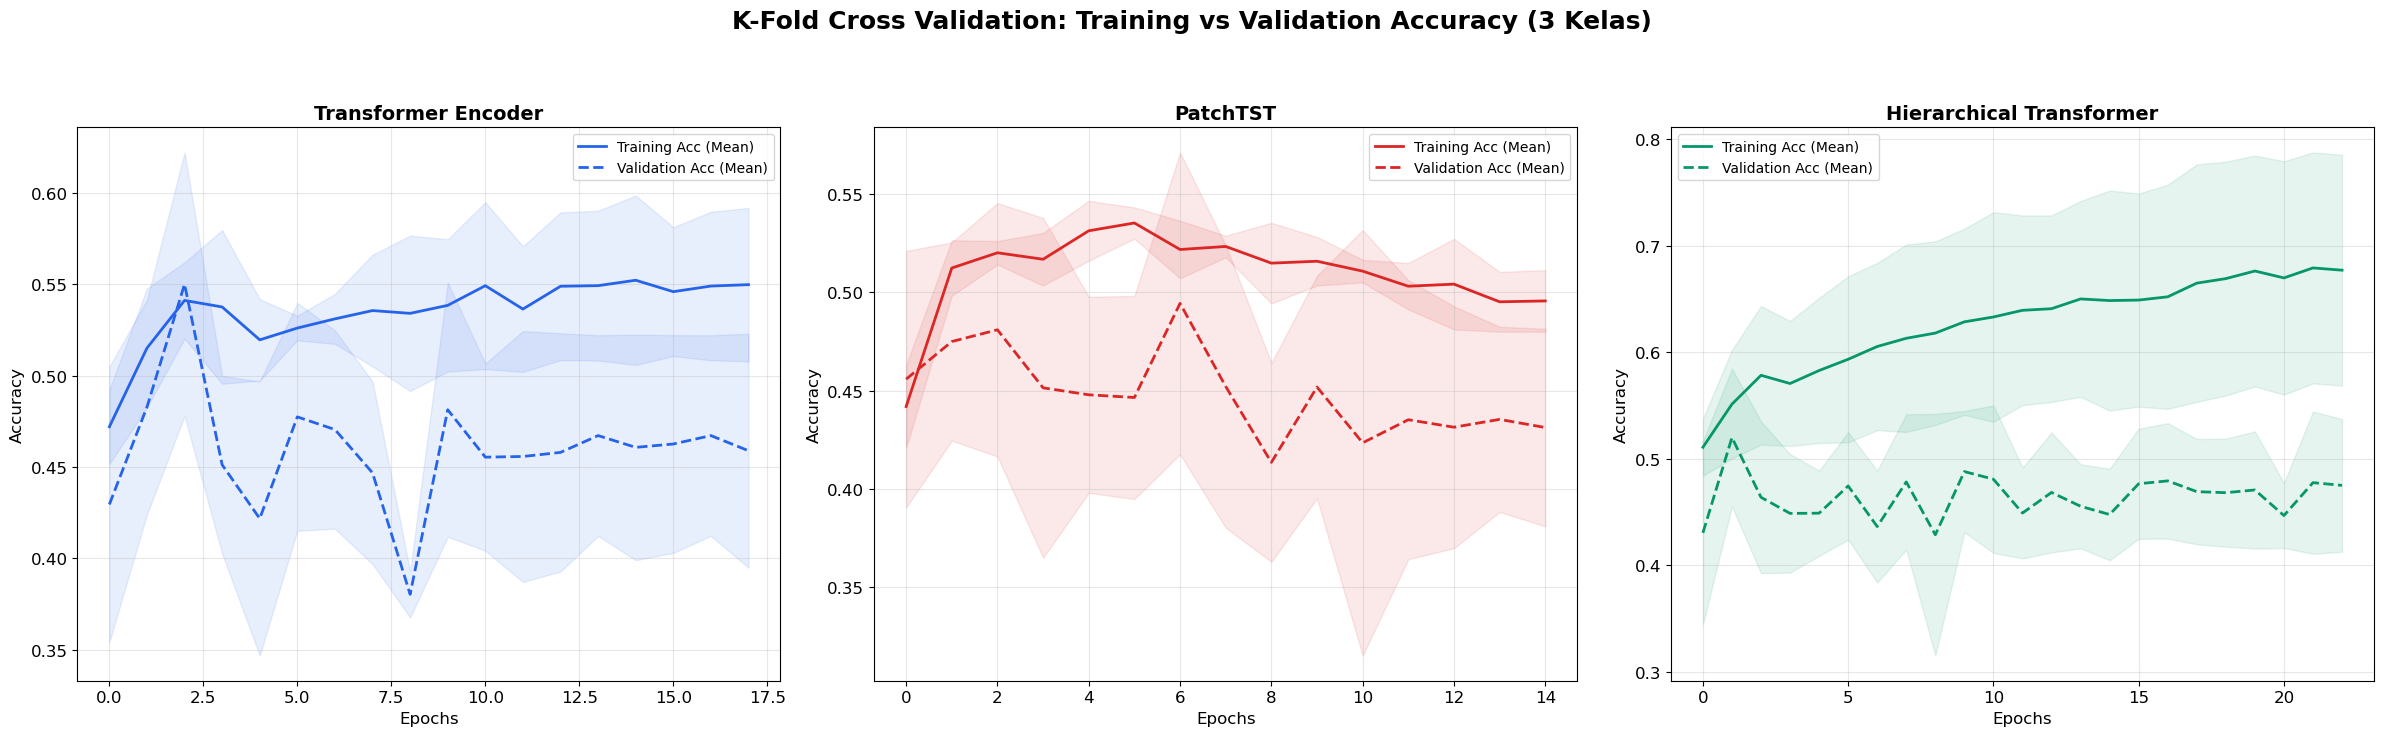

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
fig.suptitle('K-Fold Cross Validation: Training vs Validation Accuracy (3 Kelas)',
             fontsize=18, fontweight='bold', y=1.05)

for i, model_name in enumerate(MODEL_NAMES):
    ax = axes[i]
    color = MODEL_COLORS[i]
    histories = all_histories[model_name]
    max_len = max(len(h['val_acc']) for h in histories)

    train_accs = np.array([h['train_acc'] + [h['train_acc'][-1]]*(max_len - len(h['train_acc'])) for h in histories])
    val_accs = np.array([h['val_acc'] + [h['val_acc'][-1]]*(max_len - len(h['val_acc'])) for h in histories])

    mean_train = np.mean(train_accs, axis=0)
    std_train = np.std(train_accs, axis=0)
    mean_val = np.mean(val_accs, axis=0)
    std_val = np.std(val_accs, axis=0)
    epochs = np.arange(max_len)

    ax.plot(epochs, mean_train, color=color, linewidth=2, label='Training Acc (Mean)', linestyle='-')
    ax.fill_between(epochs, mean_train - std_train, mean_train + std_train, alpha=0.1, color=color)

    ax.plot(epochs, mean_val, color=color, linewidth=2, label='Validation Acc (Mean)', linestyle='--')
    ax.fill_between(epochs, mean_val - std_val, mean_val + std_val, alpha=0.1, color=color)

    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epochs')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'kfold_train_val_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Final Model Training — Semua 3 Model

Melatih ulang **semua 3 model** menggunakan **100% data training (80% DWT)**
sebanyak rata-rata best epoch dari K-Fold masing-masing model.

In [14]:
print("=" * 70)
print("🔥 FINAL MODEL TRAINING — SEMUA 3 MODEL")
print("=" * 70)

final_train_loader = DataLoader(
    ECGDataset(X_train_scaled, y_train_all),
    batch_size=CONFIG['batch_size'], shuffle=True, drop_last=True)

final_models = {}
final_train_histories = {}

for model_idx, (model_name, ModelClass) in enumerate(zip(MODEL_NAMES, model_classes)):
    avg_epoch = int(df_comparison.loc[model_idx, 'avg_best_epoch'])
    print(f"\n{'─'*50}")
    print(f"🧠 {model_name} — Target Epochs: {avg_epoch}")
    print(f"   Menggunakan 100% data training (N={len(X_train_scaled)})")
    print(f"{'─'*50}")

    model = ModelClass(CONFIG).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = optim.AdamW(model.parameters(), lr=CONFIG['learning_rate'], weight_decay=CONFIG['weight_decay'])

    history = {'train_loss': [], 'train_acc': []}
    for epoch in range(avg_epoch):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, final_train_loader, criterion, optimizer, DEVICE)
        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        if (epoch + 1) % 5 == 0 or epoch == 0 or epoch == avg_epoch - 1:
            print(f"   Ep {epoch+1:3d}/{avg_epoch} | TrLoss {tr_loss:.4f} | TrAcc {tr_acc:.3f} | {time.time()-t0:.1f}s")

    final_models[model_name] = model
    final_train_histories[model_name] = history
    
    state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    torch.save(state, OUTPUT_DIR / f'final_model_{model_name.replace(" ", "_")}.pth')
    print(f"   ✅ Model saved!")

print("\n✅ Final Training Selesai untuk semua 3 model!")

🔥 FINAL MODEL TRAINING — SEMUA 3 MODEL

──────────────────────────────────────────────────
🧠 Transformer Encoder — Target Epochs: 4
   Menggunakan 100% data training (N=2274)
──────────────────────────────────────────────────
   Ep   1/4 | TrLoss 0.9353 | TrAcc 0.482 | 19.2s
   Ep   4/4 | TrLoss 0.8028 | TrAcc 0.537 | 24.4s
   ✅ Model saved!

──────────────────────────────────────────────────
🧠 PatchTST — Target Epochs: 4
   Menggunakan 100% data training (N=2274)
──────────────────────────────────────────────────
   Ep   1/4 | TrLoss 1.0400 | TrAcc 0.423 | 20.6s
   Ep   4/4 | TrLoss 0.8762 | TrAcc 0.518 | 14.4s
   ✅ Model saved!

──────────────────────────────────────────────────
🧠 Hierarchical Transformer — Target Epochs: 6
   Menggunakan 100% data training (N=2274)
──────────────────────────────────────────────────
   Ep   1/6 | TrLoss 0.8528 | TrAcc 0.536 | 16.0s
   Ep   5/6 | TrLoss 0.7685 | TrAcc 0.548 | 22.6s
   Ep   6/6 | TrLoss 0.7586 | TrAcc 0.582 | 22.6s
   ✅ Model saved!

✅

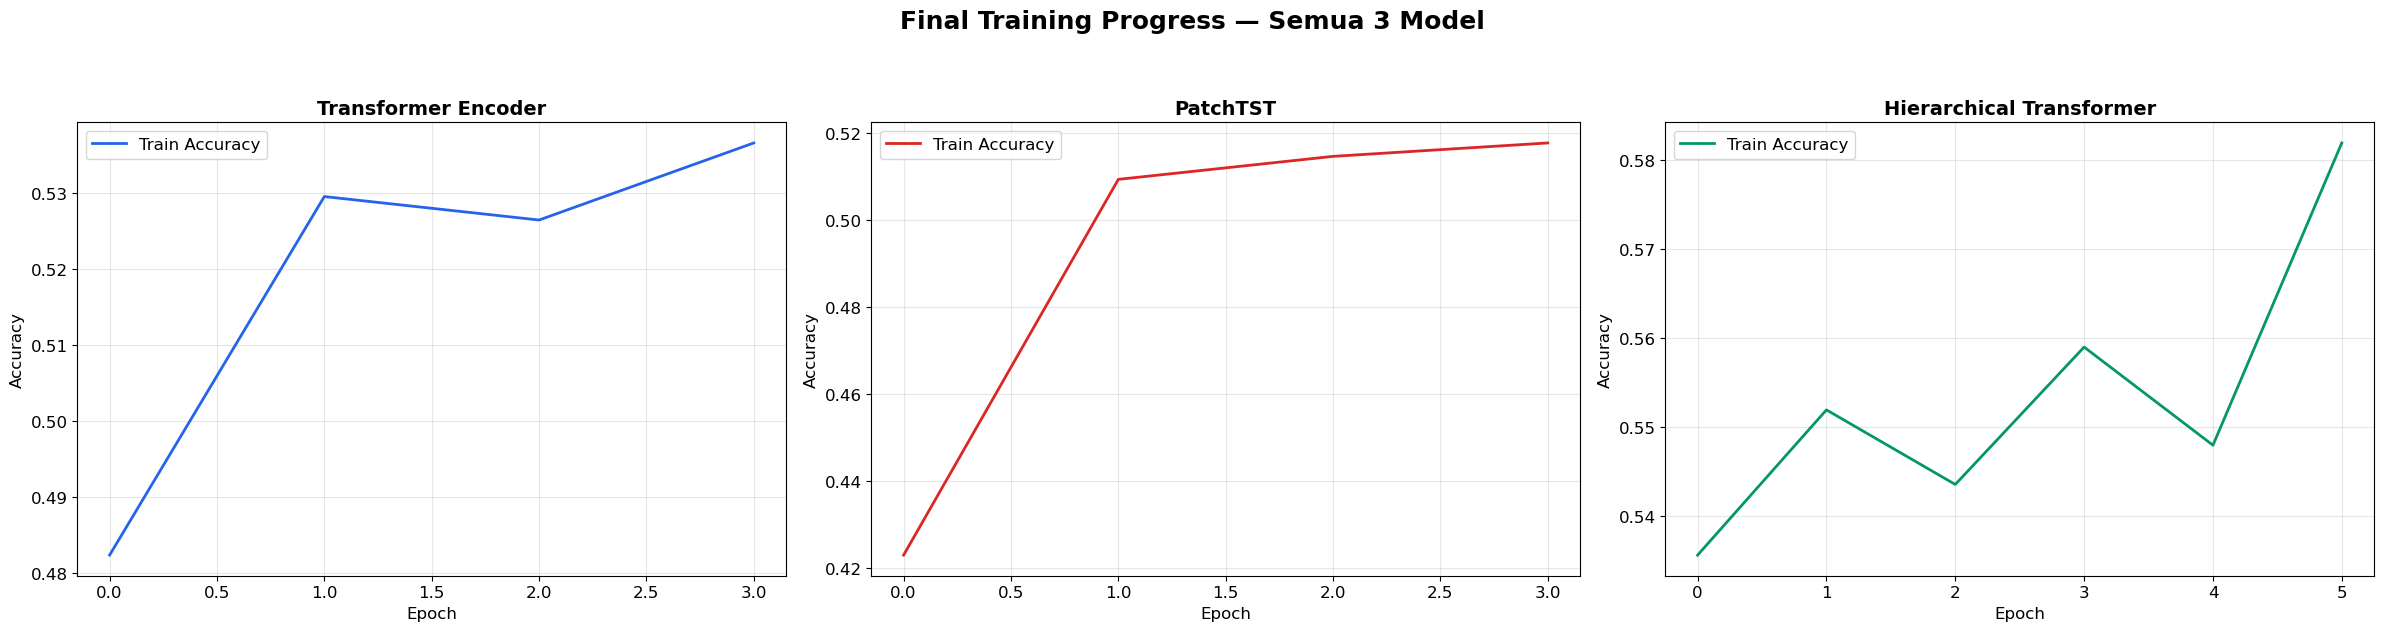

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
fig.suptitle('Final Training Progress — Semua 3 Model', fontsize=18, fontweight='bold', y=1.05)

for i, model_name in enumerate(MODEL_NAMES):
    ax = axes[i]
    h = final_train_histories[model_name]
    ax.plot(h['train_acc'], color=MODEL_COLORS[i], label='Train Accuracy', linewidth=2)
    ax.set_title(f'{model_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

---
## 10. Final Testing (20% Data DWT) — Semua 3 Model

In [16]:
print("=" * 70)
print(f"🧪 FINAL TESTING — 20% DATA DWT ({len(X_test_scaled)} segments)")
print(f"   Testing semua 3 model untuk perbandingan")
print("=" * 70)

test_loader = DataLoader(ECGDataset(X_test_scaled, y_test_all), batch_size=CONFIG['batch_size'], shuffle=False)
criterion_test = nn.CrossEntropyLoss()

all_final_test = {}

for model_name in MODEL_NAMES:
    model = final_models[model_name]
    model.eval()
    
    test_m, test_preds, test_probs, test_labels = evaluate(
        model, test_loader, criterion_test, DEVICE, N_CLASSES)
    
    patient_preds_dict = {}
    patient_probs_dict = {}
    patient_true_dict = {}
    for i, hid in enumerate(groups_test):
        if hid not in patient_preds_dict:
            patient_preds_dict[hid] = []
            patient_probs_dict[hid] = []
            patient_true_dict[hid] = test_labels[i]
        patient_preds_dict[hid].append(test_preds[i])
        patient_probs_dict[hid].append(test_probs[i])
    
    y_true_pat = []
    y_pred_pat = []
    y_prob_pat = []
    for hid in patient_preds_dict:
        y_true_pat.append(patient_true_dict[hid])
        votes = np.array(patient_preds_dict[hid])
        y_pred_pat.append(int(np.bincount(votes, minlength=N_CLASSES).argmax()))
        y_prob_pat.append(np.mean(patient_probs_dict[hid], axis=0))
    
    y_true_pat = np.array(y_true_pat)
    y_pred_pat = np.array(y_pred_pat)
    y_prob_pat = np.array(y_prob_pat)
    
    pat_m = compute_metrics(y_true_pat, y_pred_pat, y_prob_pat, N_CLASSES)
    
    all_final_test[model_name] = {
        'segment_metrics': test_m,
        'patient_metrics': pat_m,
        'y_true_pat': y_true_pat,
        'y_pred_pat': y_pred_pat,
        'y_prob_pat': y_prob_pat,
    }
    
    print(f"\n{'─'*50}")
    print(f"🧠 {model_name}")
    print(f"   Segment-Level: Acc={test_m['accuracy']:.3f} F1={test_m['f1']:.3f} AUC={test_m['auc']:.3f}")
    print(f"   Patient-Level: Acc={pat_m['accuracy']:.3f} F1={pat_m['f1']:.3f} AUC={pat_m['auc']:.3f}")

🧪 FINAL TESTING — 20% DATA DWT (533 segments)
   Testing semua 3 model untuk perbandingan

──────────────────────────────────────────────────
🧠 Transformer Encoder
   Segment-Level: Acc=0.516 F1=0.511 AUC=0.733
   Patient-Level: Acc=0.593 F1=0.585 AUC=0.774

──────────────────────────────────────────────────
🧠 PatchTST
   Segment-Level: Acc=0.508 F1=0.455 AUC=0.711
   Patient-Level: Acc=0.525 F1=0.444 AUC=0.808

──────────────────────────────────────────────────
🧠 Hierarchical Transformer
   Segment-Level: Acc=0.602 F1=0.604 AUC=0.775
   Patient-Level: Acc=0.610 F1=0.626 AUC=0.813


In [17]:
print("\n" + "=" * 70)
print("📊 PERBANDINGAN FINAL TEST — PATIENT-LEVEL (3 KELAS)")
print("=" * 70)
print(f"\n{'Model':<28} {'Accuracy':<10} {'Sensitivity':<12} {'Specificity':<12} {'F1-Score':<10} {'AUC-ROC':<10}")
print("─" * 85)
for mn in MODEL_NAMES:
    pm = all_final_test[mn]['patient_metrics']
    print(f"{mn:<28} {pm['accuracy']:<10.3f} {pm['sensitivity']:<12.3f} {pm['specificity']:<12.3f} {pm['f1']:<10.3f} {pm['auc']:<10.3f}")

best_final = max(MODEL_NAMES, key=lambda mn: all_final_test[mn]['patient_metrics']['f1'])
print(f"\n🏆 Best Final Test (by F1): {best_final}")


📊 PERBANDINGAN FINAL TEST — PATIENT-LEVEL (3 KELAS)

Model                        Accuracy   Sensitivity  Specificity  F1-Score   AUC-ROC   
─────────────────────────────────────────────────────────────────────────────────────
Transformer Encoder          0.593      0.617        0.787        0.585      0.774     
PatchTST                     0.525      0.520        0.738        0.444      0.808     
Hierarchical Transformer     0.610      0.645        0.797        0.626      0.813     

🏆 Best Final Test (by F1): Hierarchical Transformer


In [18]:
for mn in MODEL_NAMES:
    r = all_final_test[mn]
    print(f"\n{'═'*50}")
    print(f"📋 Classification Report: {mn}")
    print(f"{'═'*50}")
    print(classification_report(r['y_true_pat'], r['y_pred_pat'], target_names=le.classes_, zero_division=0))


══════════════════════════════════════════════════
📋 Classification Report: Transformer Encoder
══════════════════════════════════════════════════
              precision    recall  f1-score   support

        LVOT       0.67      0.86      0.75        14
      Non-OT       0.60      0.29      0.39        21
        RVOT       0.55      0.71      0.62        24

    accuracy                           0.59        59
   macro avg       0.61      0.62      0.59        59
weighted avg       0.59      0.59      0.57        59


══════════════════════════════════════════════════
📋 Classification Report: PatchTST
══════════════════════════════════════════════════
              precision    recall  f1-score   support

        LVOT       0.82      0.64      0.72        14
      Non-OT       0.00      0.00      0.00        21
        RVOT       0.46      0.92      0.61        24

    accuracy                           0.53        59
   macro avg       0.43      0.52      0.44        59
weighted

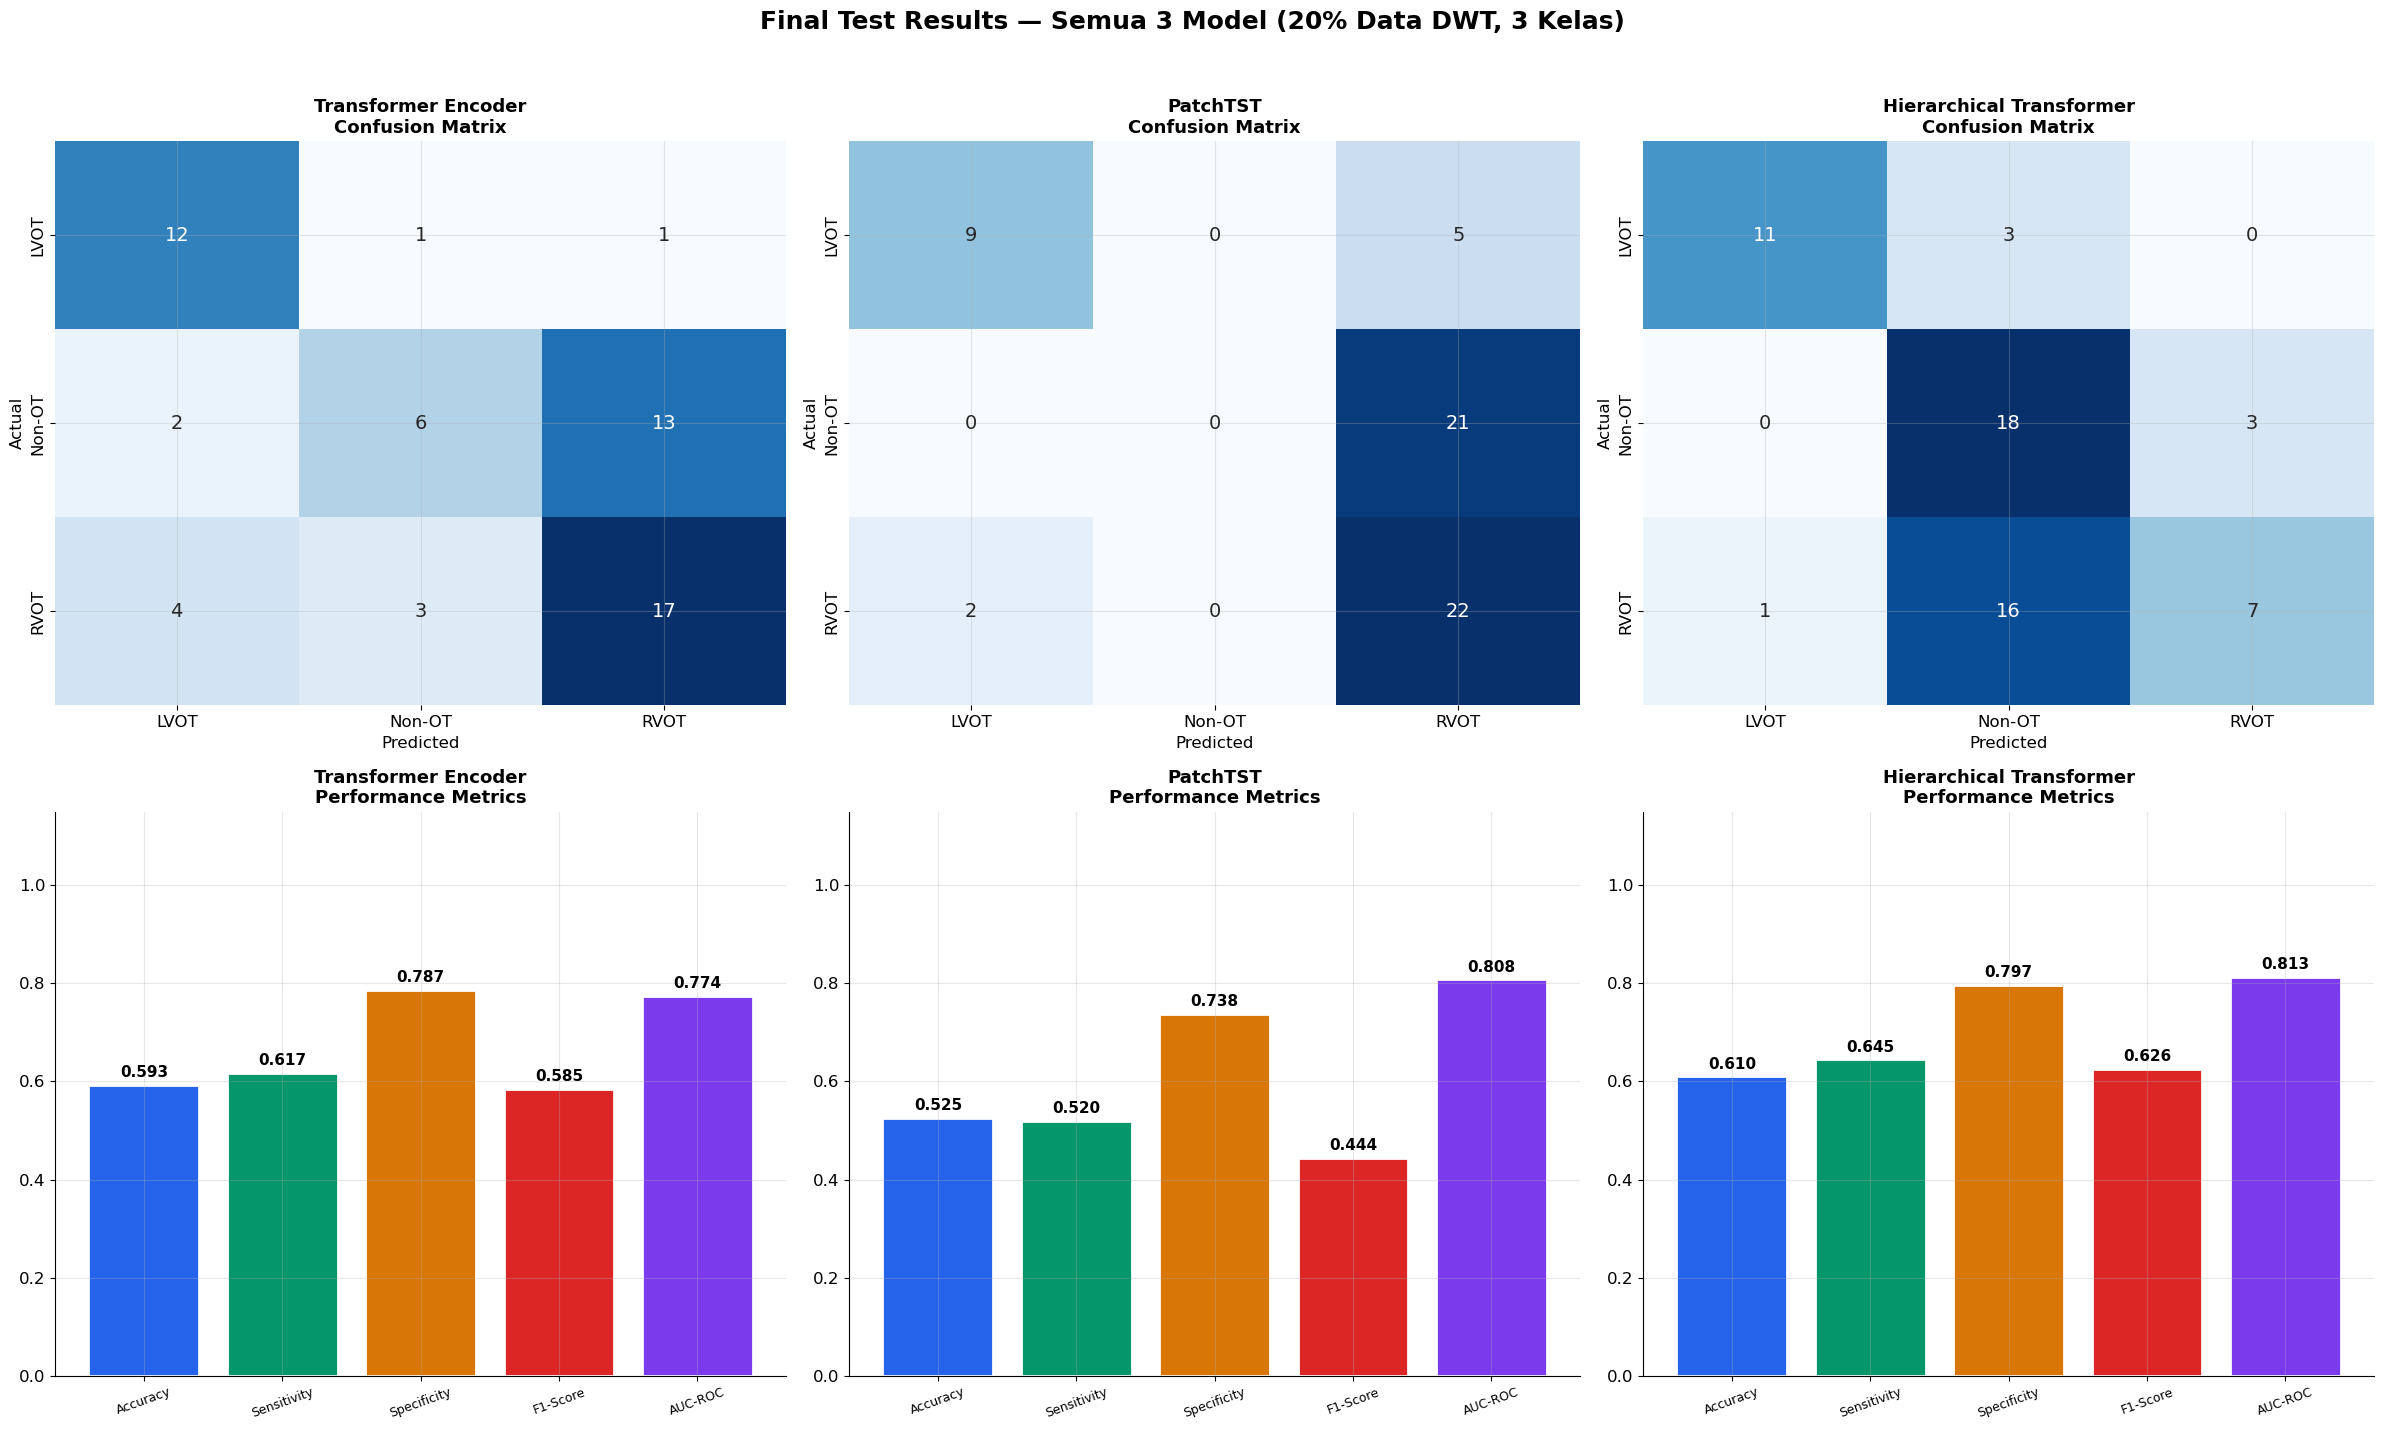

In [19]:
fig, axes = plt.subplots(2, 3, figsize=(24, 14))
fig.suptitle('Final Test Results — Semua 3 Model (20% Data DWT, 3 Kelas)',
             fontsize=18, fontweight='bold', y=1.02)

for i, mn in enumerate(MODEL_NAMES):
    r = all_final_test[mn]
    pm = r['patient_metrics']
    
    ax = axes[0, i]
    cm = confusion_matrix(r['y_true_pat'], r['y_pred_pat'], labels=list(range(N_CLASSES)))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={'size': 14}, cbar=False)
    ax.set_title(f'{mn}\nConfusion Matrix', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    
    ax = axes[1, i]
    m_names = ['Accuracy', 'Sensitivity', 'Specificity', 'F1-Score', 'AUC-ROC']
    m_keys = ['accuracy', 'sensitivity', 'specificity', 'f1', 'auc']
    m_vals = [pm[k] for k in m_keys]
    colors_m = ['#2563EB', '#059669', '#D97706', '#DC2626', '#7C3AED']
    bars = ax.bar(m_names, m_vals, color=colors_m, edgecolor='white', linewidth=2)
    for bar, val in zip(bars, m_vals):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=11)
    ax.set_title(f'{mn}\nPerformance Metrics', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.spines[['top', 'right']].set_visible(False)
    plt.sca(ax)
    plt.xticks(rotation=20, fontsize=9)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'final_test_results.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 10.5 Supplementary Analysis: Evaluasi pada Data LV Non-OT (Summit)
Karena jumlah data Summit (LV Non-OT) sangat kecil (5 pasien), data tersebut 
tidak dimasukkan ke 3 kelas eksperimen utama. 
Di bagian eksploratif ini, kita gunakan model terbaik untuk memprediksi:
"Mirip dengan kelas manakah pasien-pasien Summit ini (LVOT, RVOT, atau Non-OT)?"

In [20]:
print("\n" + "=" * 70)
print("🔎 SUPPLEMENTARY ANALYSIS: LV Non-OT (Summit)")
print("=" * 70)

if len(suppl_ids) == 0:
    print("Tidak ada data supplementary untuk dianalisis.")
else:
    best_final_model = final_models[best_final]
    best_final_model.eval()
    
    suppl_loader = DataLoader(ECGDataset(X_suppl_scaled), batch_size=CONFIG['batch_size'], shuffle=False)
    
    _, suppl_preds, suppl_probs, _ = evaluate(best_final_model, suppl_loader, criterion=None, device=DEVICE, n_classes=N_CLASSES)
    
    patient_suppl_preds = {}
    patient_suppl_probs = {}
    
    for i, hid in enumerate(groups_suppl):
        if hid not in patient_suppl_preds:
            patient_suppl_preds[hid] = []
            patient_suppl_probs[hid] = []
        patient_suppl_preds[hid].append(suppl_preds[i])
        patient_suppl_probs[hid].append(suppl_probs[i])
    
    print(f"Memprediksi {len(patient_suppl_preds)} pasien Summit menggunakan model {best_final}:")
    print("-" * 60)
    for hid in patient_suppl_preds:
        votes = np.array(patient_suppl_preds[hid])
        pred_cls_idx = int(np.bincount(votes, minlength=N_CLASSES).argmax())
        pred_cls_name = le.inverse_transform([pred_cls_idx])[0]
        
        avg_probs = np.mean(patient_suppl_probs[hid], axis=0)
        prob_str = " | ".join([f"{le.classes_[j]}: {avg_probs[j]:.1%}" for j in range(N_CLASSES)])
        
        print(f"Pasien {hid:<7} -> Diprediksi: {pred_cls_name:<10}")
        print(f"  Confidence: {prob_str}")
        print("-" * 60)


🔎 SUPPLEMENTARY ANALYSIS: LV Non-OT (Summit)
Memprediksi 5 pasien Summit menggunakan model Hierarchical Transformer:
------------------------------------------------------------
Pasien 810713  -> Diprediksi: LVOT      
  Confidence: LVOT: 59.2% | Non-OT: 27.8% | RVOT: 13.1%
------------------------------------------------------------
Pasien 888241  -> Diprediksi: LVOT      
  Confidence: LVOT: 54.0% | Non-OT: 31.1% | RVOT: 14.9%
------------------------------------------------------------
Pasien 964638  -> Diprediksi: Non-OT    
  Confidence: LVOT: 16.9% | Non-OT: 52.1% | RVOT: 30.9%
------------------------------------------------------------
Pasien 966571  -> Diprediksi: Non-OT    
  Confidence: LVOT: 16.1% | Non-OT: 52.5% | RVOT: 31.4%
------------------------------------------------------------
Pasien 1022324 -> Diprediksi: LVOT      
  Confidence: LVOT: 63.0% | Non-OT: 24.8% | RVOT: 12.2%
------------------------------------------------------------


---
## 11. SHAP Explainability (Model Terbaik)

In [21]:
import shap

best_final_model = final_models[best_final]
print("=" * 70)
print(f"🔍 SHAP EXPLAINABILITY ANALYSIS ({best_final})")
print("=" * 70)

np.random.seed(SEED)
bg_idx = np.random.choice(len(X_train_scaled), size=min(100, len(X_train_scaled)), replace=False)
background = torch.FloatTensor(X_train_scaled[bg_idx]).to(DEVICE)

n_exp = min(50, len(X_test_scaled))
exp_idx = np.random.choice(len(X_test_scaled), size=n_exp, replace=False)
exp_data = torch.FloatTensor(X_test_scaled[exp_idx]).to(DEVICE)
exp_labels = y_test_all[exp_idx]

print("\n⏳ Computing SHAP values (GradientExplainer)...")
best_final_model.eval()

try:
    explainer = shap.GradientExplainer(best_final_model, background)
    shap_values = explainer.shap_values(exp_data)
    if isinstance(shap_values, list):
        shap_vals = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    else:
        shap_vals = np.abs(shap_values)
    print("✅ SHAP computed successfully!")
except Exception as e:
    print(f"⚠️ SHAP GradientExplainer failed: {e}")
    print("   Falling back to manual gradient-based importance...")
    exp_data_grad = exp_data.clone().requires_grad_(True)
    out = best_final_model(exp_data_grad)
    out.sum().backward()
    shap_vals = np.abs(exp_data_grad.grad.cpu().numpy())
    print("✅ Gradient-based importance computed!")

if len(shap_vals.shape) == 4:
    shap_vals = shap_vals.mean(axis=-1)

🔍 SHAP EXPLAINABILITY ANALYSIS (Hierarchical Transformer)

⏳ Computing SHAP values (GradientExplainer)...
✅ SHAP computed successfully!


In [22]:
lead_imp = shap_vals.mean(axis=(0, 2))
lead_imp_df = pd.DataFrame({'Lead': LEADS, 'Importance': lead_imp}).sort_values('Importance', ascending=False)

print(f"\n{'Lead':<8} {'Importance':<12}")
print("─" * 20)
for _, row in lead_imp_df.iterrows():
    bar = '█' * int(row['Importance'] / lead_imp_df['Importance'].max() * 30)
    print(f"{row['Lead']:<8} {row['Importance']:<12.6f} {bar}")


Lead     Importance  
────────────────────
V2       0.000209     ██████████████████████████████
V4       0.000172     ████████████████████████
V1       0.000142     ████████████████████
V3       0.000119     █████████████████
aVF      0.000088     ████████████
II       0.000086     ████████████
III      0.000086     ████████████
V5       0.000079     ███████████
V6       0.000075     ██████████
aVL      0.000069     █████████
aVR      0.000053     ███████
I        0.000047     ██████



📊 Generating SHAP Summary Plot...


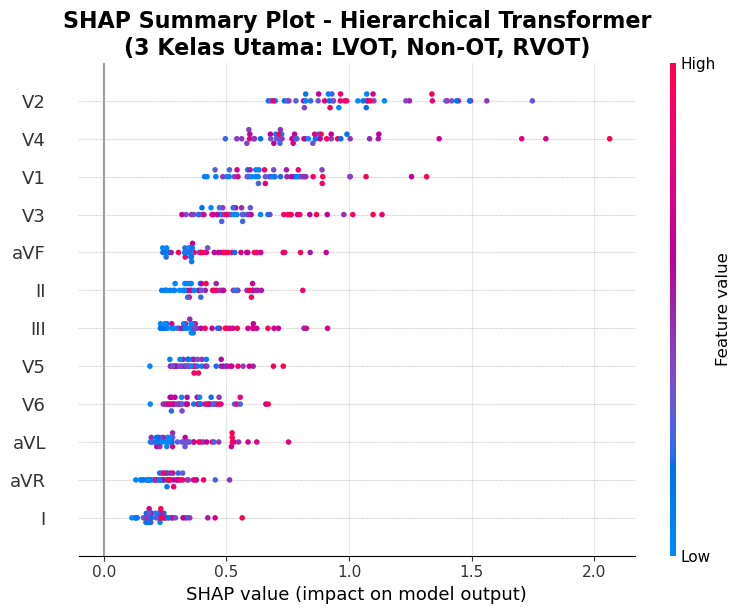

In [23]:
print("\n📊 Generating SHAP Summary Plot...")

shap_vals_2d = shap_vals.sum(axis=2)
exp_data_np = exp_data.cpu().numpy()
features_2d = np.std(exp_data_np, axis=2)

fig = plt.figure(figsize=(12, 8))
shap.summary_plot(shap_vals_2d, features=features_2d, feature_names=LEADS, show=False)
plt.title(f'SHAP Summary Plot - {best_final}\n(3 Kelas Utama: {", ".join(CLASS_NAMES)})',
          fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'shap_summary_beeswarm.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 12. Ringkasan & Simpan Hasil

In [24]:
print("\n" + "=" * 70)
print("💾 MENYIMPAN HASIL")
print("=" * 70)

df_comparison.to_csv(OUTPUT_DIR / 'kfold_comparison.csv', index=False)
print(f"   ✅ K-Fold comparison: {OUTPUT_DIR / 'kfold_comparison.csv'}")

test_rows = []
for mn in MODEL_NAMES:
    sm = all_final_test[mn]['segment_metrics']
    pm = all_final_test[mn]['patient_metrics']
    test_rows.append({'model': mn, 'level': 'segment', **sm})
    test_rows.append({'model': mn, 'level': 'patient', **pm})
test_res_df = pd.DataFrame(test_rows)
test_res_df.to_csv(OUTPUT_DIR / 'final_test_results.csv', index=False)
print(f"   ✅ Final test results: {OUTPUT_DIR / 'final_test_results.csv'}")

lead_imp_df.to_csv(OUTPUT_DIR / 'lead_importance.csv', index=False)
print(f"   ✅ Lead importance: {OUTPUT_DIR / 'lead_importance.csv'}")

with open(OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump({k: str(v) if isinstance(v, list) else v for k, v in CONFIG.items()}, f, indent=2)


💾 MENYIMPAN HASIL
   ✅ K-Fold comparison: baseline_results/kfold_comparison.csv
   ✅ Final test results: baseline_results/final_test_results.csv
   ✅ Lead importance: baseline_results/lead_importance.csv


In [25]:
print("\n" + "=" * 70)
print("📋 RINGKASAN NOTEBOOK 02: BASELINE CNN-TRANSFORMER (3 KELAS)")
print("=" * 70)

print(f"""
🔬 PIPELINE:
   DATA DWT → 80/20 Split → 5-Fold CV → Final Training (semua 3 model) → Test (20% DWT) → SHAP

🏷️ KLASIFIKASI 3 KELAS: {', '.join(CLASS_NAMES)}
   Eksperimen Utama: {len(df_main)} pasien
   Supplementary (LV Non-OT): {len(df_suppl)} pasien (Summit)

🏆 PERBANDINGAN MODEL K-FOLD (F1-Score):
   1. {MODEL_NAMES[0]:<25}: {df_comparison.loc[0, 'f1_mean']:.3f} ± {df_comparison.loc[0, 'f1_std']:.3f}
   2. {MODEL_NAMES[1]:<25}: {df_comparison.loc[1, 'f1_mean']:.3f} ± {df_comparison.loc[1, 'f1_std']:.3f}
   3. {MODEL_NAMES[2]:<25}: {df_comparison.loc[2, 'f1_mean']:.3f} ± {df_comparison.loc[2, 'f1_std']:.3f}

🧪 FINAL TEST (20% DWT Data) — Patient Level:""")

for mn in MODEL_NAMES:
    pm = all_final_test[mn]['patient_metrics']
    marker = " 🏅" if mn == best_final else ""
    print(f"   {mn:<25}: Acc={pm['accuracy']:.3f} F1={pm['f1']:.3f} AUC={pm['auc']:.3f}{marker}")

print(f"""
🔍 SHAP TOP-3 LEADS: {', '.join(lead_imp_df.head(3)['Lead'].values)}

🔜 LANGKAH SELANJUTNYA:
   → Notebook 3: Fine-Tuning (GAN augmentation → Grid Search → CNN-Transformer)
""")

print("✅ Notebook 02 Baseline CNN-Transformer (3 Kelas, Semua 3 Model) SELESAI!")


📋 RINGKASAN NOTEBOOK 02: BASELINE CNN-TRANSFORMER (3 KELAS)

🔬 PIPELINE:
   DATA DWT → 80/20 Split → 5-Fold CV → Final Training (semua 3 model) → Test (20% DWT) → SHAP

🏷️ KLASIFIKASI 3 KELAS: LVOT, Non-OT, RVOT
   Eksperimen Utama: 289 pasien
   Supplementary (LV Non-OT): 5 pasien (Summit)

🏆 PERBANDINGAN MODEL K-FOLD (F1-Score):
   1. Transformer Encoder      : 0.530 ± 0.058
   2. PatchTST                 : 0.491 ± 0.066
   3. Hierarchical Transformer : 0.539 ± 0.061

🧪 FINAL TEST (20% DWT Data) — Patient Level:
   Transformer Encoder      : Acc=0.593 F1=0.585 AUC=0.774
   PatchTST                 : Acc=0.525 F1=0.444 AUC=0.808
   Hierarchical Transformer : Acc=0.610 F1=0.626 AUC=0.813 🏅

🔍 SHAP TOP-3 LEADS: V2, V4, V1

🔜 LANGKAH SELANJUTNYA:
   → Notebook 3: Fine-Tuning (GAN augmentation → Grid Search → CNN-Transformer)

✅ Notebook 02 Baseline CNN-Transformer (3 Kelas, Semua 3 Model) SELESAI!
